# ПГО на основании анализа исторических данных

## Что мы хотим
- построить алгоритм поиска грубых ошибок на основе ИИ техник
- решать задачу ПГО быстро

In [2]:
%load_ext autoreload
%autoreload 2

#import warnings
#warnings.filterwarnings('ignore')
import sys, os

import holoviews as hv
from holoviews import opts, dim

from datetime import datetime
import pandas as pd
from IPython.display import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import random

import os
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.graph_generator import GraphGenerator
from src.tools import build_sunkey_links

pd.set_option('display.precision', 2)

## Данные

### Визуализация графа

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
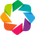

:Sankey   [Source,Target]   (Value)

In [4]:
from bokeh.plotting import show

gg = GraphGenerator(layer_sizes=[3, 5, 10, 2])
#gg = GraphGenerator(layer_sizes=[1, 2, 5, 1, 5, 2])
gg.build()
g = gg.fill_with_values(1000)

hv.extension('bokeh')
d = build_sunkey_links(g)
sankey = hv.Sankey(d)
sankey.opts(width=1000, height=400)

### Построение графа

In [41]:
pd.set_option('display.max_columns', 100)
df = gg.build_pivot_table(10_000, initial_env_volume=1000)
df.head()

,env -> 0:0,0:0 -> 1:3,env -> 0:1,0:1 -> 1:0,env -> 0:2,0:2 -> 1:2,1:0 -> 2:6,0:1 -> 1:1,1:1 -> 2:6,1:2 -> 2:9,1:3 -> 2:3,0:2 -> 1:4,1:4 -> 2:4,1:1 -> 2:0,2:0 -> 3:0,1:3 -> 2:1,2:1 -> 3:1,1:0 -> 2:2,2:2 -> 3:0,2:3 -> 3:1,2:4 -> 3:1,1:1 -> 2:5,2:5 -> 3:0,2:6 -> 3:0,1:2 -> 2:7,2:7 -> 3:1,1:3 -> 2:8,2:8 -> 3:0,2:9 -> 3:0,3:0 -> env,3:1 -> env,env,0:0,0:1,0:2,1:0,1:1,1:2,1:3,1:4,2:0,2:1,2:2,2:3,2:4,2:5,2:6,2:7,2:8,2:9,3:0,3:1,env -> 0:0_diff,0:0 -> 1:3_diff,env -> 0:1_diff,0:1 -> 1:0_diff,env -> 0:2_diff,0:2 -> 1:2_diff,1:0 -> 2:6_diff,0:1 -> 1:1_diff,1:1 -> 2:6_diff,1:2 -> 2:9_diff,1:3 -> 2:3_diff,0:2 -> 1:4_diff,1:4 -> 2:4_diff,1:1 -> 2:0_diff,2:0 -> 3:0_diff,1:3 -> 2:1_diff,2:1 -> 3:1_diff,1:0 -> 2:2_diff,2:2 -> 3:0_diff,2:3 -> 3:1_diff,2:4 -> 3:1_diff,1:1 -> 2:5_diff,2:5 -> 3:0_diff,2:6 -> 3:0_diff,1:2 -> 2:7_diff,2:7 -> 3:1_diff,1:3 -> 2:8_diff,2:8 -> 3:0_diff,2:9 -> 3:0_diff,3:0 -> env_diff,3:1 -> env_diff
0,274.73,274.73,359.66,224.67,285.49,241.95,188.61,134.99,60.07,109.22,15.52,35.76,34.30,45.58,33.53,131.76,131.76,36.06,38.24,15.52,35.76,41.39,41.39,267.36,140.52,140.52,127.45,127.45,71.32,596.33,323.56,0.00e+00,0.00,-5.68e-14,7.79,0.00,-1.21e+01,-7.79e+00,5.68e-14,1.45,12.06,0.00,-2.18,-1.78e-15,-1.45,0.00e+00,-18.68,0.00,0.00,3.79e+01,-1.70e+01,0.00,0.0,0.00,0.00,0.00,0.00,-7.79,0.0,0.0,0.00,0.0,0.00,0.0,-1.45,12.06,0.0,0.0,0.00,0.00,2.18,0.00,0.00,0.0,0.00e+00,18.68,0.0,0.00,0.0,0.00,-37.89,0.0,0.00
1,32.38,31.15,413.95,121.02,340.18,217.73,28.94,196.35,72.10,80.20,15.31,142.45,107.71,10.34,16.14,5.16,2.95,92.08,92.08,15.31,142.45,108.10,108.10,101.04,137.53,137.53,11.91,11.96,80.20,409.48,300.45,-7.66e+01,1.22,9.66e+01,-20.01,0.00,5.81e+00,0.00e+00,-1.22e+00,34.74,-5.81,2.20,0.00,0.00e+00,-34.74,0.00e+00,0.00,0.00,-0.04,1.42e-14,4.40e-02,-2.20,0.0,-1.22,96.58,0.00,-20.01,0.00,0.0,0.0,0.00,0.0,0.00,0.0,-34.74,-5.81,0.0,0.0,-2.20,0.00,0.00,0.00,0.00,0.0,0.00e+00,0.00,0.0,0.00,0.0,0.04,0.00,0.0,0.00
2,365.38,365.38,255.12,115.93,315.02,144.32,73.20,153.31,40.37,98.09,42.06,170.69,170.69,69.86,69.86,170.08,170.08,27.51,42.73,38.53,93.32,43.07,43.07,113.57,46.23,34.60,150.95,150.95,98.09,518.28,431.36,1.41e+01,0.00,-1.41e+01,0.00,15.22,0.00e+00,2.84e-14,2.29e+00,0.00,0.00,0.00,-15.22,3.53e+00,77.38,0.00e+00,0.00,11.63,0.00,0.00e+00,0.00e+00,-94.83,0.0,0.00,-14.13,0.00,0.00,0.00,0.0,0.0,0.00,0.0,-2.29,0.0,0.00,0.00,0.0,0.0,0.00,-15.22,0.00,-5.82,-77.38,0.0,0.00e+00,0.00,0.0,-11.63,0.0,0.00,0.00,0.0,0.00
3,359.37,359.37,42.69,23.35,536.49,185.20,12.52,17.64,2.46,86.75,279.55,407.78,407.78,12.57,12.57,74.15,74.15,12.53,12.53,279.55,407.78,2.61,2.60,14.99,41.95,24.66,5.67,5.67,86.75,135.10,803.44,-1.14e-13,0.00,1.69e+00,-56.49,-1.69,3.55e-15,5.65e+01,0.00e+00,0.00,0.00,0.00,0.00,0.00e+00,0.00,1.96e-03,0.00,17.29,0.00,0.00e+00,-1.96e-03,-17.29,0.0,0.00,0.00,-1.69,0.00,56.49,0.0,0.0,0.00,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.0,-1.96e-03,0.00,0.0,-17.29,0.0,0.00,0.00,0.0,0.00
4,430.34,430.34,65.44,67.30,215.31,51.26,57.74,18.83,0.63,27.79,125.46,164.05,164.05,9.70,9.70,187.36,187.34,10.32,7.98,125.46,164.05,8.02,8.02,39.75,23.47,23.47,117.52,117.52,27.79,210.75,669.50,1.69e+02,0.00,-2.07e+01,0.00,-0.76,4.83e-01,0.00e+00,-5.68e-14,0.00,0.00,0.02,2.35,0.00e+00,0.00,0.00e+00,18.62,0.00,0.00,0.00e+00,0.00e+00,-169.18,0.0,0.00,0.00,20.68,0.00,0.00,19.1,0.0,-0.48,0.0,0.00,0.0,0.00,0.00,0.0,0.0,-0.02,2.35,0.00,0.00,0.00,0.0,0.00e+00,0.00,0.0,0.00,0.0,0.00,0.00,0.0,169.16


In [42]:
flow_names = list(gg.graph.edges.keys())
nodes_names =list(gg.graph.nodes.keys())
x_cols = flow_names + nodes_names
y_cols = [col+'_diff' for col in flow_names]

print( 'количество потоков      : ', len(flow_names))
print( 'количество узлов        : ', len(nodes_names))
print(f'средняя связность графа :  {(len(flow_names) / len(nodes_names)):.1f}')
print(f'x columns               :  {x_cols[:5]}...')
print(f'y columns               :  {y_cols[:5]}...')

количество потоков      :  31
количество узлов        :  21
средняя связность графа :  1.5
x columns               :  ['env -> 0:0', '0:0 -> 1:3', 'env -> 0:1', '0:1 -> 1:0', 'env -> 0:2']...
y columns               :  ['env -> 0:0_diff', '0:0 -> 1:3_diff', 'env -> 0:1_diff', '0:1 -> 1:0_diff', 'env -> 0:2_diff']...


### Делим выборку на тренировочную, валидационную и тестовую

In [43]:
from sklearn.model_selection import train_test_split

df_train, dd = train_test_split(df.sample(len(df)), test_size=2/5)
df_val, df_test = train_test_split(dd, test_size=.5)

print(f'В тренировочной выборке :  {len(df_train)} строк')
print(f'В валидационной выборке :  {len(df_val)}   строк')
print(f'В тестовой выборке      :  {len(df_test)}  строк')

df_train_x, df_train_y = df_train[x_cols], df_train[y_cols]
df_val_x, df_val_y = df_val[x_cols], df_val[y_cols]
df_test_x, df_test_y = df_test[x_cols], df_test[y_cols]

В тренировочной выборке :  6000 строк
В валидационной выборке :  2000   строк
В тестовой выборке      :  2000  строк


In [44]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler


#mms_x, mms_y = MinMaxScaler((0, 100)), MinMaxScaler((0, 100))

#df_train_x_sc = pd.DataFrame(mms_x.fit_transform(X=df_train_x), columns=x_cols)
#df_train_y_sc = pd.DataFrame(mms_y.fit_transform(X=df_train_y), columns=y_cols)

#df_val_x_sc = pd.DataFrame(mms_x.transform(X=df_val_x), columns=x_cols)
#df_val_y_sc = pd.DataFrame(mms_y.transform(X=df_val_y), columns=y_cols)

#df_test_x_sc = pd.DataFrame(mms_x.transform(X=df_test_x), columns=x_cols)
#df_test_y_sc = pd.DataFrame(mms_y.transform(X=df_test_y), columns=y_cols)

mms = MinMaxScaler((0, 100))

df_train_sc = pd.DataFrame(mms.fit_transform(X=df_train), columns=df_train.columns)
df_val_sc = pd.DataFrame(mms.transform(X=df_val), columns=df_train.columns)
df_test_sc = pd.DataFrame(mms.transform(X=df_test), columns=df_train.columns)

df_train_x_sc, df_train_y_sc = df_train_sc[x_cols], df_train_sc[y_cols]
df_val_x_sc, df_val_y_sc = df_val_sc[x_cols], df_val_sc[y_cols]
df_test_x_sc, df_test_y_sc = df_test_sc[x_cols], df_test_sc[y_cols]

#df_train_x_sc, df_train_y_sc = df_train_x, df_train_y
#df_val_x_sc, df_val_y_sc = df_val_x, df_val_y
#df_test_x_sc, df_test_y_sc = df_test_x, df_test_y

In [45]:
df_train_sc.head()

,env -> 0:0,0:0 -> 1:3,env -> 0:1,0:1 -> 1:0,env -> 0:2,0:2 -> 1:2,1:0 -> 2:6,0:1 -> 1:1,1:1 -> 2:6,1:2 -> 2:9,1:3 -> 2:3,0:2 -> 1:4,1:4 -> 2:4,1:1 -> 2:0,2:0 -> 3:0,1:3 -> 2:1,2:1 -> 3:1,1:0 -> 2:2,2:2 -> 3:0,2:3 -> 3:1,2:4 -> 3:1,1:1 -> 2:5,2:5 -> 3:0,2:6 -> 3:0,1:2 -> 2:7,2:7 -> 3:1,1:3 -> 2:8,2:8 -> 3:0,2:9 -> 3:0,3:0 -> env,3:1 -> env,env,0:0,0:1,0:2,1:0,1:1,1:2,1:3,1:4,2:0,2:1,2:2,2:3,2:4,2:5,2:6,2:7,2:8,2:9,3:0,3:1,env -> 0:0_diff,0:0 -> 1:3_diff,env -> 0:1_diff,0:1 -> 1:0_diff,env -> 0:2_diff,0:2 -> 1:2_diff,1:0 -> 2:6_diff,0:1 -> 1:1_diff,1:1 -> 2:6_diff,1:2 -> 2:9_diff,1:3 -> 2:3_diff,0:2 -> 1:4_diff,1:4 -> 2:4_diff,1:1 -> 2:0_diff,2:0 -> 3:0_diff,1:3 -> 2:1_diff,2:1 -> 3:1_diff,1:0 -> 2:2_diff,2:2 -> 3:0_diff,2:3 -> 3:1_diff,2:4 -> 3:1_diff,1:1 -> 2:5_diff,2:5 -> 3:0_diff,2:6 -> 3:0_diff,1:2 -> 2:7_diff,2:7 -> 3:1_diff,1:3 -> 2:8_diff,2:8 -> 3:0_diff,2:9 -> 3:0_diff,3:0 -> env_diff,3:1 -> env_diff
0,10.55,8.19,53.69,28.05,23.00,23.48,20.32,33.07,11.62,15.52,2.62,2.56,2.78,38.77,33.06,2.70,2.76,26.21,19.54,2.82,2.60,16.44,21.99,26.85,17.08,13.67,12.09,13.00,15.73,51.99,14.38,56.72,44.22,51.24,59.84,62.49,51.61,56.36,45.70,44.63,54.12,47.31,42.40,42.44,56.86,44.48,50.23,53.21,56.18,52.88,49.23,51.15,52.27,42.92,50.46,63.45,50.37,52.61,38.95,46.27,53.72,48.68,40.81,47.03,43.07,42.58,44.58,58.24,62.45,62.68,59.94,55.73,45.7,40.71,50.99,48.44,53.24,52.71,49.37,46.53,53.10,43.14,52.93
1,65.30,50.72,9.61,0.40,28.07,6.50,0.49,10.44,3.33,0.93,40.49,13.67,18.95,8.53,10.46,48.56,49.61,0.02,0.03,25.68,22.00,5.47,6.53,4.88,8.36,7.66,14.12,15.18,1.22,11.70,75.20,56.07,44.22,51.24,70.18,67.97,54.52,57.53,45.70,33.22,48.94,47.31,33.67,63.06,56.04,48.78,43.27,48.84,56.18,52.53,51.39,37.89,52.27,42.92,50.46,63.45,50.37,51.69,38.95,46.27,46.96,48.68,40.81,31.13,41.87,42.58,49.88,58.24,62.45,49.79,59.95,26.52,45.7,40.71,46.25,52.01,49.30,53.15,49.37,46.53,53.74,43.14,51.86
2,13.07,10.15,42.11,30.61,20.58,10.28,31.91,17.53,19.59,7.97,11.28,11.49,10.06,17.78,13.84,0.19,0.27,19.35,20.94,12.13,11.67,1.40,1.68,36.67,3.66,4.92,13.07,10.26,8.08,38.18,19.73,56.07,44.22,51.24,59.84,60.51,49.55,60.27,42.92,45.59,56.27,47.19,33.68,42.44,56.04,48.78,63.05,45.29,60.55,52.88,50.08,52.20,52.27,42.92,50.46,63.45,50.37,52.61,57.64,46.27,53.72,48.68,40.81,47.03,41.87,47.52,46.10,58.08,62.45,49.79,59.94,55.73,45.7,40.71,46.25,52.01,45.32,52.71,56.02,46.85,53.10,43.14,51.86
3,16.06,12.47,32.91,31.70,34.46,19.20,12.98,6.10,4.59,16.06,3.28,19.74,15.35,1.15,0.98,10.67,10.90,32.17,32.67,3.53,17.82,4.92,5.87,16.49,10.00,8.96,12.22,13.13,17.48,35.80,29.08,56.07,44.22,51.24,57.15,67.97,51.61,57.32,45.70,49.00,54.12,47.31,35.80,42.44,56.04,48.78,46.75,49.26,56.18,51.34,49.71,52.20,52.27,42.92,50.46,63.45,50.37,52.61,38.95,46.27,53.72,50.14,40.81,51.42,41.87,42.58,44.58,58.24,62.45,49.79,56.32,55.73,45.7,40.71,46.25,52.01,49.30,52.71,49.37,46.53,58.10,43.14,51.86
4,48.64,34.51,13.85,19.35,26.36,6.07,13.83,5.21,8.02,4.70,22.73,20.81,18.21,11.65,9.93,10.90,15.71,13.75,16.82,24.46,21.14,1.43,1.70,18.59,3.26,2.92,33.64,36.16,4.76,35.13,51.76,72.34,48.19,42.79,59.84,67.25,42.59,58.31,49.35,45.59,54.12,40.17,31.76,42.44,56.04,48.78,48.72,49.26,56.18,52.88,49.49,38.01,58.88,42.92,29.24,62.16,50.37,52.61,41.20,36.26,53.72,48.68,40.81,47.03,41.87,42.58,44.58,47.93,62.45,46.96,59.94,55.73,45.7,40.71,46.25,52.01,49.30,52.71,49.37,46.53,53.10,43.14,66.30


## Модель

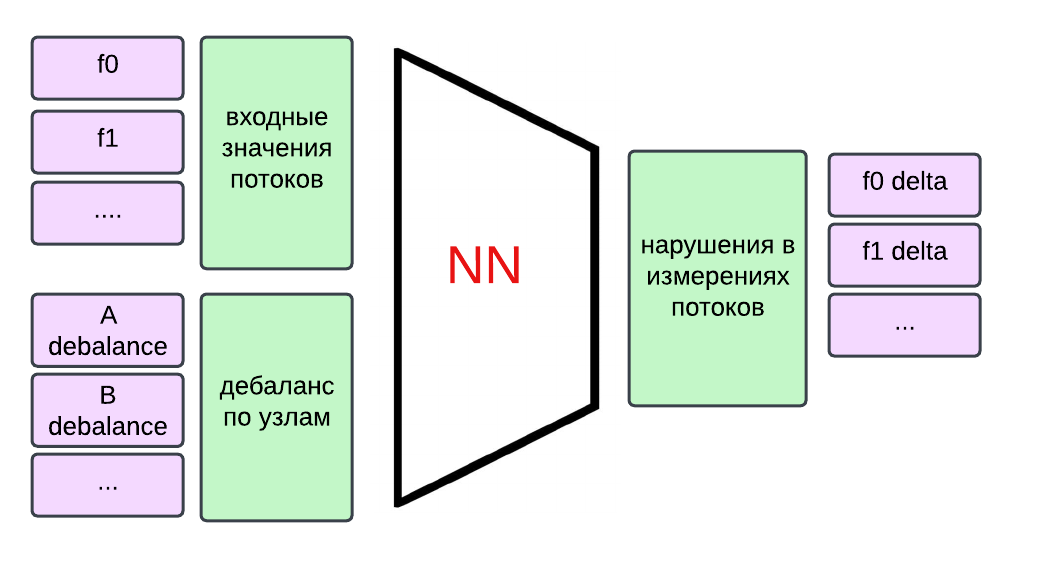

In [46]:
Image("../sources/nn.png", width=800, height=800)

In [47]:
x_data = torch.tensor(df[x_cols].values, dtype=torch.float32)
y_data = torch.tensor(df[y_cols].values, dtype=torch.float32)

x_train, x_1, y_train, y_1 = train_test_split(x_data, y_data, test_size=0.5, shuffle=False)
x_valid, x_test, y_valid, y_test = train_test_split(x_1, y_1, test_size=0.5, shuffle=False)

print('x_train:', x_train.shape)
print('y_train:', y_train.shape)
print('x_valid:', x_valid.shape)
print('y_valid:', y_valid.shape)
print('x_test:', x_test.shape)
print('y_test:', y_test.shape)


x_train, x_valid = x_train.to(device), x_valid.to(device)
y_train, y_valid = y_train.to(device), y_valid.to(device)
x_test, y_test = x_test.to(device), y_test.to(device)

x_train: torch.Size([5000, 52])
y_train: torch.Size([5000, 31])
x_valid: torch.Size([2500, 52])
y_valid: torch.Size([2500, 31])
x_test: torch.Size([2500, 52])
y_test: torch.Size([2500, 31])


### Создаем модель

In [48]:
input_dim = df_train_x.shape[1]
output_dim = df_train_y.shape[1]

class Mod(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.ReLU(input_dim, input_dim * 2),
            nn.ReLU(input_dim * 2, output_dim),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork().to("cpu")
print(model)


NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=52, out_features=104, bias=True)
    (1): ReLU()
    (2): Linear(in_features=104, out_features=31, bias=True)
    (3): ReLU()
    (4): Linear(in_features=31, out_features=31, bias=True)
  )
)


In [50]:
learning_rate = 0.003
epochs = 10000
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=mod.parameters(), lr=learning_rate)

#logits = model(x_train)

def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = correct / len(y_pred) * 100
    return acc


# Empty loss lists to track values
epoch_count, train_loss_values, valid_loss_values = [], [], []

# Loop through the data
for epoch in range(epochs):

    # Put the model in training mode
    model.train()

    y_logits = model(x_train).squeeze() # forward pass to get predictions; squeeze the logits into the same shape as the labels
    y_pred = torch.round(torch.sigmoid(y_logits)) # convert logits into prediction probabilities

    loss = loss_fn(y_logits, y_train) # compute the loss   
    acc = accuracy_fn(y_train.int(), y_pred) # calculate the accuracy; convert the labels to integers

    optimizer.zero_grad() # reset the gradients so they don't accumulate each iteration
    loss.backward() # backward pass: backpropagate the prediction loss
    optimizer.step() # gradient descent: adjust the parameters by the gradients collected in the backward pass
    
    # Put the model in evaluation mode
    model.eval() 

    with torch.inference_mode():
        valid_logits = model(x_valid).squeeze()
        valid_pred = torch.round(torch.sigmoid(valid_logits))    

        valid_loss = loss_fn(valid_logits, y_valid)
        valid_acc = accuracy_fn(y_valid.int(), valid_pred)    
    
    # Print progress a total of 20 times
    if epoch % int(epochs / 5) == 0:
        print(f'Epoch: {epoch:4.0f} | Train Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Validation Loss: {valid_loss:.5f}, Accuracy: {valid_acc:.2f}%')

        epoch_count.append(epoch)
        train_loss_values.append(loss.detach().numpy())
        valid_loss_values.append(valid_loss.detach().numpy())

Epoch:    0 | Train Loss: 5.34296, Accuracy: 1325.40% | Validation Loss: 4.10588, Accuracy: 1333.04%
Epoch: 2000 | Train Loss: 5.34296, Accuracy: 1325.40% | Validation Loss: 4.10588, Accuracy: 1333.04%
Epoch: 4000 | Train Loss: 5.34296, Accuracy: 1325.40% | Validation Loss: 4.10588, Accuracy: 1333.04%
Epoch: 6000 | Train Loss: 5.34296, Accuracy: 1325.40% | Validation Loss: 4.10588, Accuracy: 1333.04%
Epoch: 8000 | Train Loss: 5.34296, Accuracy: 1325.40% | Validation Loss: 4.10588, Accuracy: 1333.04%


### Обучение

In [12]:
BATCH_SIZE = 128
EPOCHS = 200

yyyymmddHHMM = datetime.now().strftime('%Y%m%d%H%M')
log_subdir = f"{yyyymmddHHMM}_batch{BATCH_SIZE}_layers{len(mod.layers)}"

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    #min_delta=.001,
    patience=10,
    verbose=2, 
    mode='min',
    restore_best_weights=True
)

save_model = tf.keras.callbacks.ModelCheckpoint(
    filepath='mod.hdf5',
    save_best_only=True,
    monitor='val_loss',
    verbose=0,
    mode='min'
)

tensorboard = tf.keras.callbacks.TensorBoard(
    f'logs/{log_subdir}',
    batch_size=BATCH_SIZE,
    update_freq='batch'
)

# callbacks argument only takes a list
cb = [early_stop, save_model, tensorboard]

history = mod.fit(
    df_train_x_sc, df_train_y_sc,
    shuffle=True,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=cb,
    validation_data=(df_val_x_sc, df_val_y_sc)
)

Epoch 1/200
94/94 [==============================] - 1s 4ms/step - loss: 20.9455 - mae: 20.9455 - val_loss: 17.5184 - val_mae: 17.5184
Epoch 2/200
94/94 [==============================] - 0s 3ms/step - loss: 17.5066 - mae: 17.5066 - val_loss: 17.4525 - val_mae: 17.4525
Epoch 3/200
94/94 [==============================] - 0s 2ms/step - loss: 17.6037 - mae: 17.6037 - val_loss: 17.5935 - val_mae: 17.5935
Epoch 4/200
94/94 [==============================] - 0s 3ms/step - loss: 17.5300 - mae: 17.5300 - val_loss: 17.3919 - val_mae: 17.3919
Epoch 5/200
94/94 [==============================] - 0s 3ms/step - loss: 17.4553 - mae: 17.4553 - val_loss: 17.4764 - val_mae: 17.4764
Epoch 6/200
94/94 [==============================] - 0s 3ms/step - loss: 17.4166 - mae: 17.4166 - val_loss: 17.4466 - val_mae: 17.4466
Epoch 7/200
94/94 [==============================] - 0s 3ms/step - loss: 17.4607 - mae: 17.4607 - val_loss: 17.8201 - val_mae: 17.8201
Epoch 8/200
94/94 [==============================] - 0s

## Оценка результатов модели

### На тестовой выборке

In [ ]:
df_test_res = mod.predict(df_test_x_sc)
mse = np.mean(np.power(df_test_y_sc - df_test_res, 2), axis=1)
print(f'MAE на тестовой выборке (нормированный) :  {np.mean(mse):.2f}')
df_test_res = mms.inverse_transform(df_test_res)
df_test_res = pd.DataFrame(df_test_res, columns=df_test_y.columns)
mse = np.mean(np.power(df_test_y - df_test_res, 2), axis=1)
print(f'MAE на тестовой выборке (оригинальный)  : {np.mean(mse):.2f}')
df_test_res.head()

### Визуальный анализ 

In [ ]:
pd.set_option('display.max_columns', 30)

d = df_test_x.copy()
df_test_res.index = d.index.copy()
#df_test_res[df_test_res < 0] = 0
d = pd.concat([d, df_test_res], axis=1)

d.sample(5)

In [ ]:
d1 = df_test.sample(10)
th = 10

for i1, row1 in d1[y_cols].iterrows():
    plt.figure(figsize=(20, 5))
    row2 = d[y_cols][d.index == i1].iloc[0]
    mask = [(abs(r1) > th) or (abs(r2) > th) for r1, r2 in zip(row1, row2)]
    #mask = [True for i in range(len(row1))]
    row11 = row1[mask]
    row22 = row2[mask]
    w=.2
    indexes1 = [ii - w/2 for ii in range(len(row11.index))]
    indexes2 = [ii + w/2 for ii in range(len(row22.index))]
    plt.bar(indexes1, row11, width=w, label='ошибка измерения потока')
    plt.bar(indexes2, row22, width=w, label='NN ошибка измерения потока')
    plt.axhline(y=0, color='black')
    plt.xticks(range(len(row11)), row11.index)
    plt.title(f'{i1} ({(sum(mask) * 100 / len(row1)):<.1f} % сильно испорченных потоков)' )
    plt.legend()
    if row11.max() < th or row22.max() < th:
        plt.ylim((min(row1.min(), row2.min()), th))
    plt.show()


In [23]:
from sklearn.metrics import r2_score, d2_absolute_error_score, mean_absolute_percentage_error, mean_absolute_error, mean_squared_error

th = 10
mask = (df_test[y_cols] > th) + (d[y_cols] > th)

df_test_10 = df_test[y_cols] * mask
d_10 = d[y_cols] * mask

r2 = r2_score(df_test[y_cols], d[y_cols])
d2 = d2_absolute_error_score(df_test[y_cols], d[y_cols])
mae = mean_absolute_error(df_test[y_cols], d[y_cols])
mse = mean_squared_error(df_test[y_cols], d[y_cols])


r2_more_than_10 = r2_score(df_test_10, d_10)
d2_more_than_10 = d2_absolute_error_score(df_test_10, d_10)
mae_more_than_10 = mean_absolute_error(df_test_10, d_10)

df_res = pd.DataFrame(
    data = [('R2', r2, r2_more_than_10), #коэфф детерминации
            ('D2', d2, d2_more_than_10), 
            ('MAE', mae, mae_more_than_10)
           ],
        columns = ['metric', 'score', 'score > 10']
)

df_res

,metric,score,score > 10
0,R2,-13.81,-2.61
1,D2,-3.59,-0.18
2,MAE,40.50,5.00


In [15]:
df_test_10

,env -> 0:0_diff,0:0 -> 1:0_diff,1:0 -> 2:3_diff,0:0 -> 1:1_diff,1:1 -> 2:0_diff,2:0 -> 3:5_diff,1:0 -> 2:1_diff,2:1 -> 3:1_diff,1:1 -> 2:2_diff,2:2 -> 3:9_diff,2:3 -> 3:1_diff,1:0 -> 2:4_diff,2:4 -> 3:4_diff,2:0 -> 3:0_diff,3:0 -> 4:7_diff,...,6:0 -> 7:18_diff,7:18 -> 8:9_diff,7:19 -> 8:4_diff,8:0 -> env_diff,7:18 -> 8:1_diff,8:1 -> env_diff,8:2 -> env_diff,7:11 -> 8:3_diff,8:3 -> env_diff,8:4 -> env_diff,8:5 -> env_diff,8:6 -> env_diff,8:7 -> env_diff,8:8 -> env_diff,8:9 -> env_diff
970,0.00,0.00,0.0,137.83,-0.0,29.39,0.00,0.0,0.00,0.00,0.00,0.0,-0.0,0.00,0.0,...,0.0,0.0,0.0,0.00,-0.0,0.0,0.0,0.0,0.0,0.0,0.00,-0.00,0.0,0.0,0.0
9632,0.00,-0.00,0.0,42.99,0.0,0.00,0.00,0.0,0.00,-0.00,-0.00,0.0,0.0,0.00,0.0,...,0.0,0.0,0.0,0.00,0.0,0.0,-0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0
10572,122.39,42.18,0.0,0.00,0.0,-0.00,0.00,0.0,0.00,0.00,-0.00,0.0,0.0,15.59,0.0,...,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,25.02,0.00,0.0,0.0,0.0
16154,-0.00,0.00,-0.0,0.00,0.0,0.00,128.89,0.0,0.00,0.00,0.00,0.0,0.0,-0.00,0.0,...,-0.0,0.0,0.0,0.00,0.0,0.0,-0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0
4094,0.00,0.00,0.0,0.00,0.0,0.00,0.00,0.0,0.00,36.78,0.00,0.0,0.0,0.00,0.0,...,0.0,0.0,0.0,38.53,0.0,0.0,0.0,0.0,0.0,0.0,0.00,-0.00,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1371,0.00,0.00,0.0,0.00,0.0,-0.00,0.00,-0.0,0.00,0.00,0.00,0.0,0.0,0.00,0.0,...,0.0,0.0,0.0,27.84,-0.0,0.0,-0.0,0.0,0.0,-0.0,0.00,0.00,0.0,0.0,0.0
8373,0.00,0.00,0.0,0.00,0.0,0.00,0.00,0.0,0.00,0.00,0.00,0.0,0.0,-0.00,0.0,...,0.0,0.0,0.0,0.00,0.0,0.0,-0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0
17446,0.00,0.00,0.0,0.00,0.0,0.00,0.00,0.0,0.00,0.00,0.00,0.0,0.0,0.00,-0.0,...,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0
10723,0.00,0.00,0.0,0.00,0.0,0.00,0.00,0.0,35.71,0.00,0.00,0.0,0.0,0.00,0.0,...,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0
